In [1]:
# ==============================================================================
# DOU Vacancies Analytics Pipeline — Фінальна Демо-Версія (End-to-End)
# ==============================================================================

In [2]:
# ------------------------------------------------------------------------------
# Крок 1: Імпорт необхідних бібліотек та налаштування середовища
# ------------------------------------------------------------------------------

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [3]:
# Налаштування стилю графіків
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100

print("Конвеєр активовано. Бібліотеки завантажено успішно.")

Конвеєр активовано. Бібліотеки завантажено успішно.


In [4]:
# ------------------------------------------------------------------------------
# Крок 2: Симуляція сирих даних (Raw Ingestion Layer)
# Створюємо брудні дані, які зазвичай приходять після скрапінгу HTML-сторінок DOU
# ------------------------------------------------------------------------------

In [5]:
print("\nКрок 2: Генерація сирих (брудних) даних з DOU.ua")

np.random.seed(3024)  # Для відтворюваності результатів
n_vacancies = 300

# Списки для генерації
mock_titles = [
    "Junior Machine Learning Engineer", "Middle Data Scientist", 
    "Senior Data Engineer", "Lead AI Specialist", "Python Developer (NLP focus)",
    "Computer Vision Engineer", "Data Analyst", "Senior ML Ops Engineer"
]
mock_companies = ["SoftServe", "EPAM Systems", "Luxoft", "Genesis", "MacPaw", "Preply", "Ajax Systems"]
mock_locations = ["Київ", "Львів", "Remote", "віддалено", "Одеса", "Харків", "Київ, Офіс"]
mock_salaries = ["$600-1200", "$2000-3500", "$4500-6000", "Договірна", "$1500-2500", "not specified"]

# Приклади сирих описів із тегами та змішаним текстом
mock_descriptions = [
    "<div>Шукаємо спеціаліста! Requirements: strong Python skills, SQL, pandas. Experience with PyTorch or TensorFlow is a big plus. Робота в офісі або remote.</div>",
    "<p>We are looking for a Data Engineer. Must have: AWS, Apache Spark, Python and SQL. Experience with Docker/Kubernetes.</p>",
    "<span>Join our team as an ML Engineer. Big Data pipelines, Git, CI/CD, classical Machine Learning, scikit-learn, and deep learning architectures (PyTorch).</span>",
    "<div>Strong analytical background. Requirements: Tableau, SQL, Excel, Python. Understanding of A/B testing and statistics.</div>"
]

raw_data = {
    'id': range(10000, 10000 + n_vacancies),
    'title': np.random.choice(mock_titles, n_vacancies),
    'company': np.random.choice(mock_companies, n_vacancies),
    'location': np.random.choice(mock_locations, n_vacancies, p=[0.3, 0.2, 0.3, 0.1, 0.04, 0.04, 0.02]),
    'salary_raw': np.random.choice(mock_salaries, n_vacancies, p=[0.15, 0.2, 0.1, 0.3, 0.15, 0.1]),
    'description_raw': np.random.choice(mock_descriptions, n_vacancies)
}

df_raw = pd.DataFrame(raw_data)
print(f"Згенеровано {df_raw.shape[0]} сирих вакансій для демо-пайплайну.")


Крок 2: Генерація сирих (брудних) даних з DOU.ua
Згенеровано 300 сирих вакансій для демо-пайплайну.


In [6]:
# ------------------------------------------------------------------------------
# Крок 3: Очищення та трансформація даних (Transformation & Cleaning)
# ------------------------------------------------------------------------------

In [7]:
print("\nКрок 3: Запуск конвеєра очищення та нормалізації даних...")

def clean_html(text):
    """Видалення HTML-тегів з тексту."""
    return re.sub(r'<[^>]*>', '', text)

def normalize_location(loc):
    """Приведення локацій до єдиного стандарту."""
    loc = str(loc).lower().strip()
    if 'віддалено' in loc or 'remote' in loc:
        return 'Remote'
    if 'київ' in loc:
        return 'Київ'
    if 'львів' in loc:
        return 'Львів'
    if 'харків' in loc:
        return 'Харків'
    if 'одеса' in loc:
        return 'Одеса'
    return 'Інші міста'

def parse_salary(salary_str, mode='min'):
    """Парсинг числових значень зарплат із текстових рядків."""
    salary_str = str(salary_str).replace(' ', '')
    if '$' not in salary_str or '-' not in salary_str:
        return np.nan
    try:
        nums = re.findall(r'\d+', salary_str)
        if len(nums) == 2:
            return float(nums[0]) if mode == 'min' else float(nums[1])
    except:
        return np.nan
    return np.nan

# Створення копії для обробки
df_processed = df_raw.copy()

# Застосування трансформацій
df_processed['description_clean'] = df_processed['description_raw'].apply(clean_html)
df_processed['location'] = df_processed['location'].apply(normalize_location)
df_processed['salary_min'] = df_processed['salary_raw'].apply(lambda x: parse_salary(x, 'min'))
df_processed['salary_max'] = df_processed['salary_raw'].apply(lambda x: parse_salary(x, 'max'))

# Екстракція досвіду з назви посади (проста евристика для демо)
def extract_experience(title):
    title = title.lower()
    if 'junior' in title: return 1
    if 'senior' in title: return 5
    if 'lead' in title: return 7
    return 3  # Middle за замовчуванням

df_processed['experience_years'] = df_processed['title'].apply(extract_experience)

print("Тексти очищено від HTML. Локації уніфіковано. Зарплати зіндексовано.")


Крок 3: Запуск конвеєра очищення та нормалізації даних...
Тексти очищено від HTML. Локації уніфіковано. Зарплати зіндексовано.


In [8]:
# ------------------------------------------------------------------------------
# Крок 4: NLP-модуль витягування навичок (Skills Extraction)
# ------------------------------------------------------------------------------

In [9]:
print("\nКрок 4: Запуск NLP-модуля для екстракції Hard Skills")

# Словник ключових технологій для пошуку
skills_dictionary = [
    'Python', 'SQL', 'PyTorch', 'TensorFlow', 'AWS', 'Docker', 
    'Kubernetes', 'Tableau', 'Excel', 'Git', 'CI/CD', 'Spark', 'scikit-learn'
]

def extract_skills(text):
    """Шукає збіги технологій у тексті опису вакансії."""
    found_skills = []
    for skill in skills_dictionary:
        # Використовуємо regex з boundary (\b) для уникнення часткових збігів
        pattern = r'\b' + re.escape(skill.lower()) + r'\b'
        if re.search(pattern, text.lower()):
            found_skills.append(skill)
    return found_skills

df_processed['extracted_skills'] = df_processed['description_clean'].apply(extract_skills)
print("Технологічний стек успішно витягнуто з текстів описів вакансій.")


Крок 4: Запуск NLP-модуля для екстракції Hard Skills
Технологічний стек успішно витягнуто з текстів описів вакансій.


In [10]:
# ------------------------------------------------------------------------------
# Крок 5: Розвеsnowflake-аналіз та Візуалізація інсайтів (EDA Layer)
# ------------------------------------------------------------------------------


Крок 5: Візуалізація аналітичних метрик


C:\Users\mfese\AppData\Local\Temp\ipykernel_17956\3674367591.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_processed, y='location', order=df_processed['location'].value_counts().index, palette="viridis")


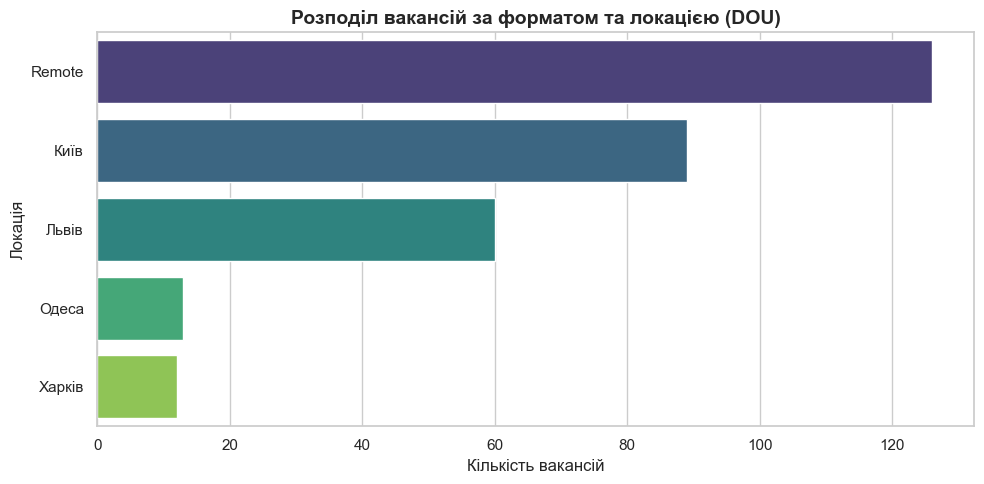

C:\Users\mfese\AppData\Local\Temp\ipykernel_17956\3674367591.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=skills_df.head(10), x='Count', y='Skill', palette="magma")


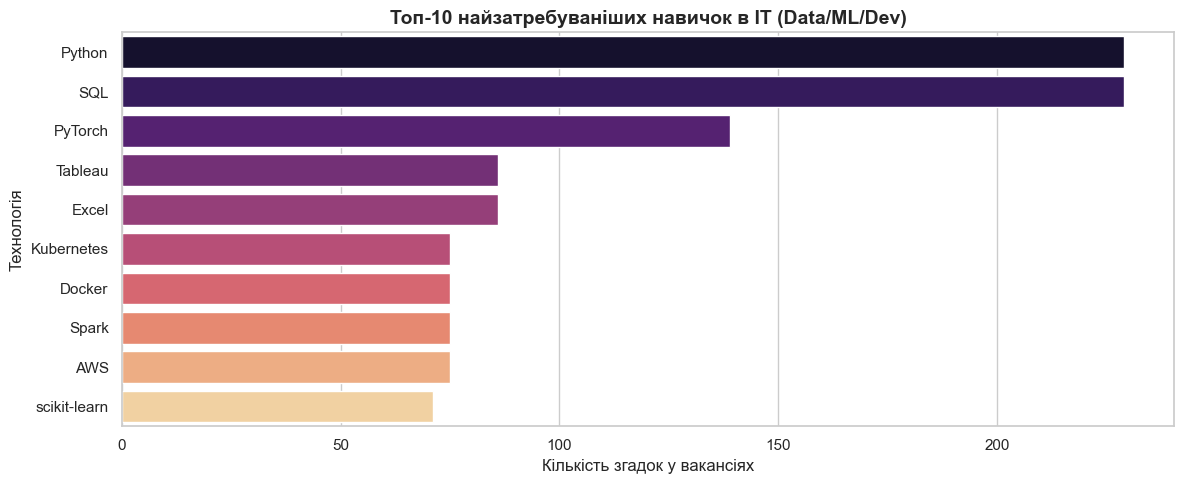

C:\Users\mfese\AppData\Local\Temp\ipykernel_17956\3674367591.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtered_salary, x='experience_years', y='salary_min', palette="coolwarm")


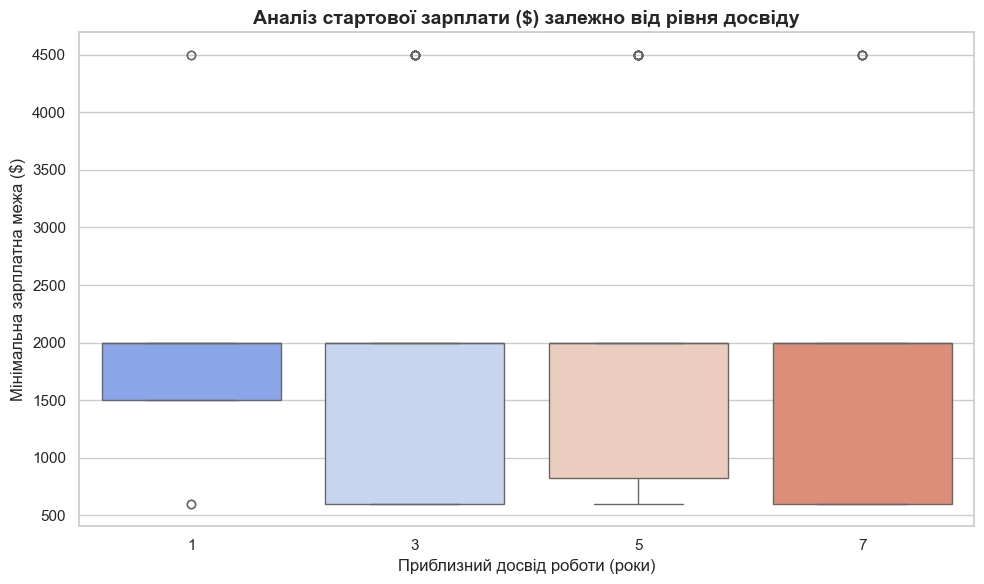

In [11]:
print("\nКрок 5: Візуалізація аналітичних метрик")

# Графік 1: Топ локацій
plt.figure(figsize=(10, 5))
sns.countplot(data=df_processed, y='location', order=df_processed['location'].value_counts().index, palette="viridis")
plt.title("Розподіл вакансій за форматом та локацією (DOU)", fontsize=14, fontweight='bold')
plt.xlabel("Кількість вакансій")
plt.ylabel("Локація")
plt.tight_layout()
plt.show()

# Графік 2: Топ навичок (Skills Frequency)
plt.figure(figsize=(12, 5))
all_skills_flat = [skill for sublist in df_processed['extracted_skills'] for skill in sublist]
skills_counts = Counter(all_skills_flat)
skills_df = pd.DataFrame(skills_counts.items(), columns=['Skill', 'Count']).sort_values(by='Count', ascending=False)

sns.barplot(data=skills_df.head(10), x='Count', y='Skill', palette="magma")
plt.title("Топ-10 найзатребуваніших навичок в IT (Data/ML/Dev)", fontsize=14, fontweight='bold')
plt.xlabel("Кількість згадок у вакансіях")
plt.ylabel("Технологія")
plt.tight_layout()
plt.show()

# Графік 3: Залежність зарплати від досвіду (Там, де вказана вилка)
plt.figure(figsize=(10, 6))
df_filtered_salary = df_processed.dropna(subset=['salary_min'])

sns.boxplot(data=df_filtered_salary, x='experience_years', y='salary_min', palette="coolwarm")
plt.title("Аналіз стартової зарплати ($) залежно від рівня досвіду", fontsize=14, fontweight='bold')
plt.xlabel("Приблизний досвід роботи (роки)")
plt.ylabel("Мінімальна зарплатна межа ($)")
plt.tight_layout()
plt.show()

In [12]:
# ------------------------------------------------------------------------------
# Фінальний звіт (Metrics Summary)
# ------------------------------------------------------------------------------

In [13]:
print("\n" + "="*50)
print("ДЕМО-ВЕРСІЮ ПАЙПЛАЙНУ УСПІШНО ВИКОНАНО")
print("="*50)
print(f"Всього оброблено вакансій: {df_processed.shape[0]}")
print(f"Медіанна стартова зарплата на ринку: ${df_filtered_salary['salary_min'].median():.0f}")
print(f"Топ-3 найпопулярніші технології: {', '.join(skills_df['Skill'].head(3).tolist())}")
print(f"Частка віддаленої роботи (Remote): {(df_processed['location'] == 'Remote').mean() * 100:.1f}%")
print("="*50)


ДЕМО-ВЕРСІЮ ПАЙПЛАЙНУ УСПІШНО ВИКОНАНО
Всього оброблено вакансій: 300
Медіанна стартова зарплата на ринку: $2000
Топ-3 найпопулярніші технології: Python, SQL, PyTorch
Частка віддаленої роботи (Remote): 42.0%
